In [ ]:
# @title Link to the dataset
https://www.kaggle.com/datasets/lteodor/identify-the-author

In [ ]:
# =================================================
# Imports for all the necessary libraries for:
#Data preprocessing (Spark, scikit-learn)
#Machine learning (TensorFlow/Keras for RNN models)
#Data visualization (matplotlib, seaborn)
#Data manipulation (pandas, numpy)
# =================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from pyspark.sql.functions import trim, lower, upper, regexp_replace, col
from pyspark.ml.feature import Tokenizer, StopWordsRemover
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from pyspark.sql import SparkSession

In [ ]:
# Load dataset
spark = SparkSession.builder \
    .appName("AuthorAttributionRNN") \
    .getOrCreate()
df = spark.read.csv("labeled_sentence_corpus.csv", header=True, inferSchema=True)
df.printSchema()
df.show(20, truncate=100)

# Creates a Spark session for distributed data processing
#Loads the dataset from CSV file into a Spark DataFrame to display the data

root
 |-- text: string (nullable = true)
 |-- author: string (nullable = true)

+----------------------------------------------------------------------------------------------------+---------------------+
|                                                                                                text|               author|
+----------------------------------------------------------------------------------------------------+---------------------+
|                    I am as positive that yesterday was Sunday as I am that I sit upon this chair.""|                  EAP|
|                                                                       """By the Waters of the Brook|          "" by Rev."|
|                           Even for thy woes I love thee-even for thy woes- Thy beauty and thy woes.|                  EAP|
|                                                                   Negotium perambulans in tenebris.|                  HPL|
|                                    Perdita 

In [ ]:
# Check for nulls and drop rows with nulls
initial_count = df.count()
df_cleaned = df.na.drop()
cleaned_count = df_cleaned.count()

print(f"Number of rows with null values dropped: {initial_count - cleaned_count}")

Number of rows with null values dropped: 0


In [ ]:
print(f"Number of rows: {df.count()}")
print(f"Number of columns: {len(df.columns)}")

Number of rows: 50952
Number of columns: 2


In [ ]:
df.dropDuplicates()

DataFrame[text: string, author: string]

In [ ]:

# Remove leading/trailing spaces from 'text' and 'author'
df = df.withColumn("text", trim(col("text")))
df = df.withColumn("author", trim(col("author")))

# Convert 'text' and 'author' to lowercase for consistency
df = df.withColumn("text", lower(col("text")))
df = df.withColumn("author", lower(col("author")))

# Remove special characters from 'text' (keeping keeping only alphanumeric characters and spaces)
df = df.withColumn("clean_text", regexp_replace(col("text"), "[^a-z0-9\\s]", ""))

df.select("text","clean_text", "author").show(20, truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------+
|                                                                            text|                                                                      clean_text|              author|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------+
|i am as positive that yesterday was sunday as i am that i sit upon this chair.""|   i am as positive that yesterday was sunday as i am that i sit upon this chair|                 eap|
|                                                   """by the waters of the brook|                                                      by the waters of the brook|         "" by rev."|
|       even for thy woes i love thee-even for thy woes- thy beauty and thy

In [ ]:
#Splits text into individual words (tokenization)
tokenizer = Tokenizer(inputCol="clean_text", outputCol="clean_words")
df = tokenizer.transform(df)

#Removes common stop words (like "the", "and", "is") to reduce noise
remover = StopWordsRemover(inputCol="clean_words", outputCol="filtered")
df = remover.transform(df)

df.select("clean_text","clean_words", "filtered", "author").show(5, truncate=80)

+-----------------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------+-----------+
|                                                                   clean_text|                                                                     clean_words|                                                            filtered|     author|
+-----------------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------+-----------+
|i am as positive that yesterday was sunday as i am that i sit upon this chair|[i, am, as, positive, that, yesterday, was, sunday, as, i, am, that, i, sit, ...|                     [positive, yesterday, sunday, sit, upon, chair]|        eap|
|                               

,author,count
0,hpl,19666
1,eap,15998
2,mws,11528


/tmp/ipython-input-1252621849.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=author_counts_pandas.head(3), x="author", y="count", palette="Set2")


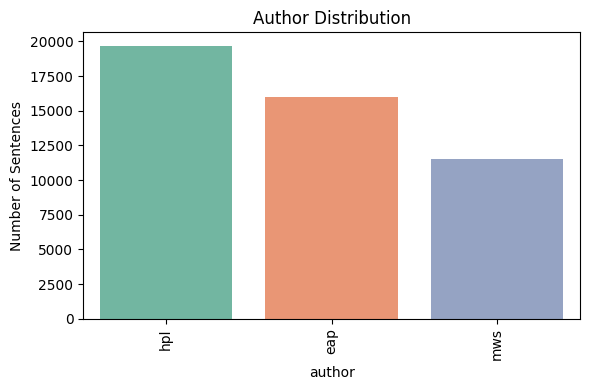

In [ ]:
# Counts sentences per author and converts to pandas for visualization
author_counts_spark = df.groupBy("author").count().orderBy("count", ascending=False)

# Convert to pandas DataFrame for plotting
author_counts_pandas = author_counts_spark.toPandas()

# Display the numerical distribution
display(author_counts_pandas.head(3))

# Plot the distribution
plt.figure(figsize=(6, 4))
sns.barplot(data=author_counts_pandas.head(3), x="author", y="count", palette="Set2")
plt.title("Author Distribution")
plt.ylabel("Number of Sentences")
plt.xticks(rotation=90) # Rotate labels for better readability
plt.tight_layout()
plt.show()

In [ ]:
# Get author counts using Spark
author_counts_spark = df.groupBy("author").count().orderBy("count", ascending=False)

# Convert to pandas DataFrame for display
author_counts_pandas = author_counts_spark.toPandas()

print("Author Distribution (Numerical):")
display(author_counts_pandas.head(3))

Author Distribution (Numerical):


,author,count
0,hpl,19666
1,eap,15998
2,mws,11528


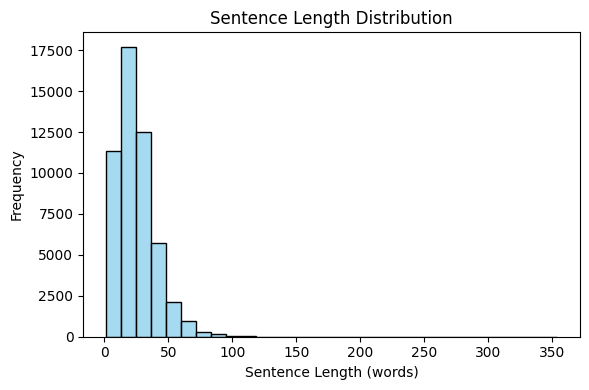

In [ ]:
from pyspark.sql.functions import size

#Adds a column with sentence length (word count) for analysis
df = df.withColumn("sentence_length", size(df["clean_words"]))

#Creates a histogram showing distribution of sentence lengths
plt.figure(figsize=(6, 4))
sns.histplot(df.toPandas()["sentence_length"], bins=30, kde=False, color="skyblue")
plt.title("Sentence Length Distribution")
plt.xlabel("Sentence Length (words)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

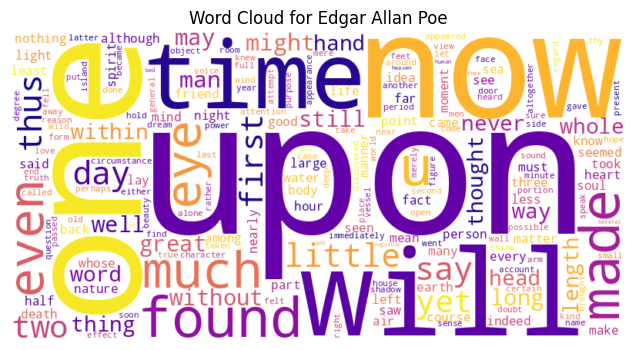

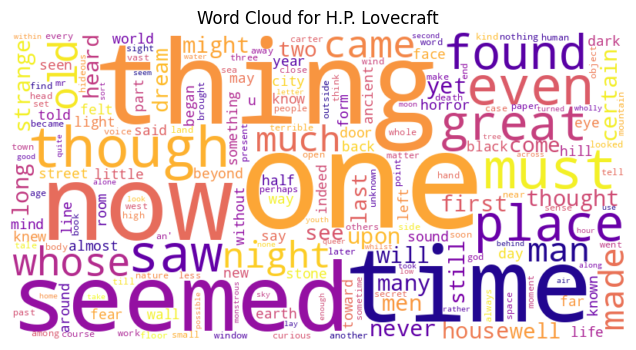

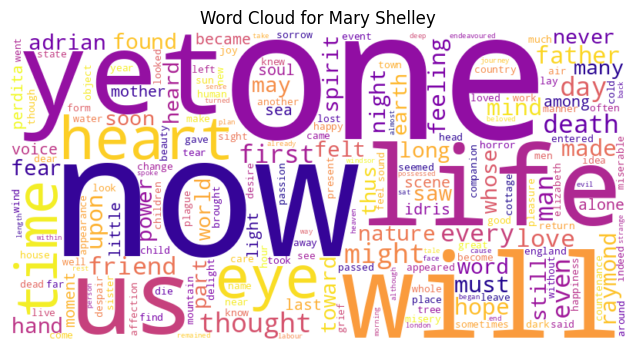

In [ ]:
from wordcloud import WordCloud

# Define author_map based on the data observed for better visusualisation
author_map = {
    "eap": "Edgar Allan Poe",
    "hpl": "H.P. Lovecraft",
    "mws": "Mary Shelley"
}

# Convert Spark DataFrame to Pandas DataFrame for WordCloud
pandas_df_text = df.select("author", "text").toPandas()

#Word Clouds for each author
for author, name in author_map.items():

# Filter pandas DataFrame
    text_data = " ".join(pandas_df_text[pandas_df_text["author"] == author]["text"].astype(str).tolist())
    wc = WordCloud(width=800, height=400,
                   background_color="white",
                   colormap="plasma").generate(text_data)

    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for {name}")
    plt.show()

In [ ]:
# 4. Convert to Pandas for Tensorflow model training
# Collect text + labels
#Replace text with filtered text
texts = df.select("filtered").rdd.map(lambda x: x[0]).collect()
labels = df.select("author").rdd.map(lambda x: x[0]).collect()

pandas_df = pd.DataFrame({"filtered": texts, "author": labels})
pandas_df.head()


,filtered,author
0,"[positive, yesterday, sunday, sit, upon, chair]",eap
1,"[waters, brook]",""""" by rev."""
2,"[even, thy, woes, love, theeeven, thy, woes, t...",eap
3,"[negotium, perambulans, tenebris]",hpl
4,"[perdita, tried, read, countenance, angrily, a...",mws


In [ ]:
# 5. Prepare for TensorFlow
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Count occurrences of each author
author_counts = pandas_df['author'].value_counts()

# Identify authors with only one entry
authors_to_remove = author_counts[author_counts == 1].index

# Remove rows with authors that have only one entry
pandas_df_filtered = pandas_df[~pandas_df['author'].isin(authors_to_remove)].copy()

# Join the list of words into a single string
pandas_df_filtered['filtered_text'] = pandas_df_filtered['filtered'].apply(lambda x: ' '.join(x))


# Encode labels
le = LabelEncoder()
y_filtered = le.fit_transform(pandas_df_filtered["author"].values)

X_train, X_test, y_train, y_test = train_test_split(
    pandas_df_filtered["filtered_text"].values, y_filtered, test_size=0.2, stratify=y_filtered, random_state=42
)

# Keras tokenization (re-fit on the filtered training data)
vocab_size = 20000
keras_tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
keras_tokenizer.fit_on_texts(X_train)

# Convert to padded sequences
maxlen = 200
X_train_seq = pad_sequences(keras_tokenizer.texts_to_sequences(X_train), maxlen=maxlen, padding="post")
X_test_seq  = pad_sequences(keras_tokenizer.texts_to_sequences(X_test),  maxlen=maxlen, padding="post")

print("Train shape:", X_train_seq.shape, " Test shape:", X_test_seq.shape)

Train shape: (38534, 200)  Test shape: (9634, 200)


In [ ]:
# 6. Build & Train RNN (Keras)
embedding_dim = 100

#Defines and compiles a bidirectional LSTM model for text classification
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(len(le.classes_), activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

history = model.fit(
    X_train_seq, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
482/482 ━━━━━━━━━━━━━━━━━━━━ 380s 777ms/step - accuracy: 0.3624 - loss: 1.8265 - val_accuracy: 0.6079 - val_loss: 0.9265
Epoch 2/5
482/482 ━━━━━━━━━━━━━━━━━━━━ 373s 773ms/step - accuracy: 0.6920 - loss: 0.8129 - val_accuracy: 0.8008 - val_loss: 0.6486
Epoch 3/5
482/482 ━━━━━━━━━━━━━━━━━━━━ 389s 807ms/step - accuracy: 0.8821 - loss: 0.4365 - val_accuracy: 0.8110 - val_loss: 0.6319
Epoch 4/5
482/482 ━━━━━━━━━━━━━━━━━━━━ 371s 771ms/step - accuracy: 0.9241 - loss: 0.3116 - val_accuracy: 0.8034 - val_loss: 0.7183
Epoch 5/5
482/482 ━━━━━━━━━━━━━━━━━━━━ 387s 780ms/step - accuracy: 0.9434 - loss: 0.2310 - val_accuracy: 0.8067 - val_loss: 0.8232


In [ ]:
# 7. Evaluate Model on test set
y_pred_probs = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Get the unique labels in the test set and their corresponding names
unique_test_labels = np.unique(y_test)
target_names_filtered = le.inverse_transform(unique_test_labels)

print(classification_report(y_test, y_pred, labels=unique_test_labels, target_names=target_names_filtered))

302/302 ━━━━━━━━━━━━━━━━━━━━ 43s 139ms/step
Test Accuracy: 0.8133693170022835
                                                                                                                                                precision    recall  f1-score   support

                                                                                                                                     "" a poem       0.00      0.00      0.00         1
                                                                                                                                        "" and       0.00      0.00      0.00         1
                                                                                                                            "" armitage said."       0.00      0.00      0.00         1
                                                                                                                 "" by andrew francis lockhart       0.00      0.00      0.00         1
 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# 8. Saves the trained model and preprocessing objects for future use
model.save("author_rnn_model.h5")

import json
with open("tokenizer.json", "w") as f:
    f.write(keras_tokenizer.to_json())
